Обучение модели и максимизация прибыли через "Логистическую регрессию"

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем подготовленные данные
df = pd.read_csv('../data/bank_loan_data_features.csv')

# Выбираем фичи для обучения
X = df[['age', 'monthly_income', 'credit_limit', 'utilization_rate', 'delinquencies_30_plus']]
y = df['is_default']

# Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабируем признаки (критично для логистической регрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")


Размер обучающей выборки: 8000
Размер тестовой выборки: 2000


In [12]:
# Обучаем логистическую регрессию
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Получаем вероятности дефолта для тестовой выборки
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"ROC-AUC модели на тестовой выборке: {roc_auc_score(y_test, y_pred_proba):.4f}")


ROC-AUC модели на тестовой выборке: 0.7140


In [13]:
# Инициализируем список для прибыли
profits = []

for t in thresholds:
    # Если вероятность дефолта ниже порога 't' — одобряем (1), иначе — отказываем (0)
    decision = np.where(test_financials['prob_default'] < t, 1, 0)
    
    # ИСПРАВЛЕНО: Добавили внешние скобки для логического условия перед умножением
    interest_gain = np.sum(
        ((decision == 1) & (test_financials['is_default'] == 0)) * 
        (test_financials['loan_amount'] * test_financials['interest_rate'])
    )
    
    # ИСПРАВЛЕНО: То же самое для расчета потерь
    loan_loss = np.sum(
        ((decision == 1) & (test_financials['is_default'] == 1)) * 
        test_financials['loan_amount']
    )
    
    # Итоговая прибыль портфеля при данном пороге
    total_profit = interest_gain - loan_loss
    profits.append(total_profit)

# Находим точку максимума
best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
max_profit = profits[best_idx]

print(f"Оптимальный порог одобрения для бизнеса: {best_threshold:.2f}")
print(f"Максимальная прибыль на тестовом портфеле: {max_profit:,.2f} руб.")


Оптимальный порог одобрения для бизнеса: 0.14
Максимальная прибыль на тестовом портфеле: 9,330,651.00 руб.


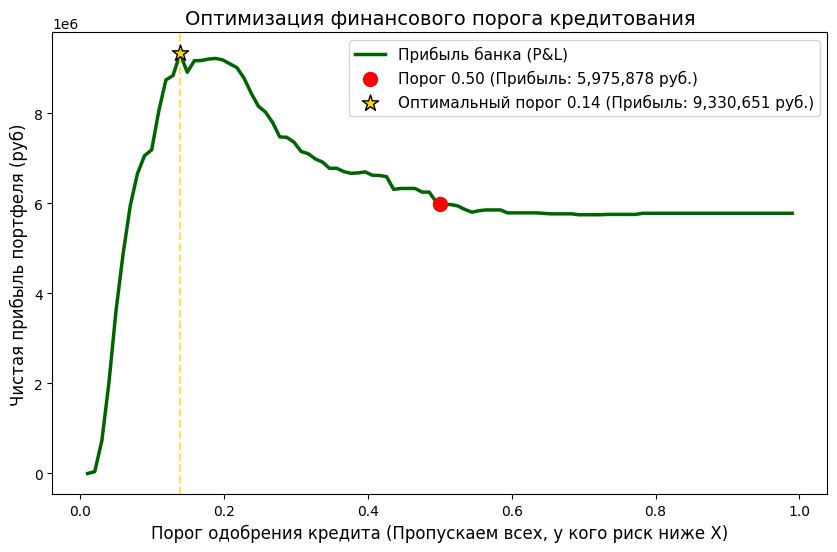

Поиск оптимального порога принес банку дополнительно: 3,354,773.00 рублей!


In [14]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, label='Прибыль банка (P&L)', color='darkgreen', linewidth=2.5)

# Базовый порог 0.5
p_at_50 = profits[np.abs(thresholds - 0.5).argmin()]
plt.scatter(0.5, p_at_50, color='red', s=100, zorder=5, label=f'Порог 0.50 (Прибыль: {p_at_50:,.0f} руб.)')

# Оптимальный порог
plt.scatter(best_threshold, max_profit, color='gold', s=150, edgecolors='black', marker='*', zorder=6, 
            label=f'Оптимальный порог {best_threshold:.2f} (Прибыль: {max_profit:,.0f} руб.)')

plt.title('Оптимизация финансового порога кредитования', fontsize=14)
plt.xlabel('Порог одобрения кредита (Пропускаем всех, у кого риск ниже X)', fontsize=12)
plt.ylabel('Чистая прибыль портфеля (руб)', fontsize=12)
plt.legend(fontsize=11)
plt.axvline(x=best_threshold, color='gold', linestyle='--', alpha=0.7)
plt.show()

additional_money = max_profit - p_at_50
print(f"Поиск оптимального порога принес банку дополнительно: {additional_money:,.2f} рублей!")
